<a href="https://colab.research.google.com/github/ImSayvi/Sztuczna-Inteligencja/blob/main/lab1_070326.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.20.0


In [3]:
observations = 1000
xs = np.random.uniform(low=-10,high=10,size=(observations,1))
zs = np.random.uniform(low=-10,high=10,size=(observations,1))
inputs=np.column_stack((xs,zs))
print(inputs.shape)

(1000, 2)


In [4]:
noise = np.random.uniform(low=-1,high=1,size=(observations,1))
targets = 2*xs - 3*zs + 5 + noise
np.savez('TF_dataset',inputs=inputs,targets=targets)
print(targets.shape)

(1000, 1)


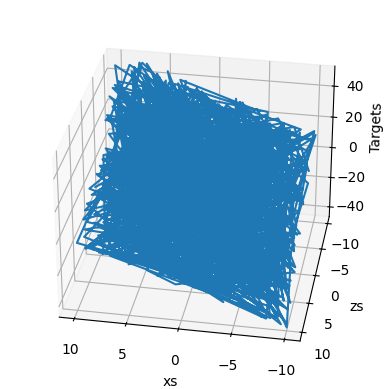

In [5]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.plot(xs,zs,targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [6]:
init_range= 0.1
weights = np.random.uniform(low=-init_range,high=init_range,size=(2,1))
biases = np.random.uniform(low=-init_range,high=init_range,size=1)
print(weights,biases)


[[0.06058015]
 [0.0559874 ]] [-0.00226623]


In [7]:
targets = targets.reshape(observations,1)
eta = 0.02
for i in range (100):
  outputs = np.dot(inputs,weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas **2)/2/observations
  print(loss)

  deltas_scaled = deltas/observations
  weights = weights - eta * np.dot(inputs.T,deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)


221.6740543474076
37.25390707399573
14.780747506846703
11.684447800403202
10.926674675787465
10.465107786566595
10.053832289192945
9.662670955613264
9.287429988479456
8.927069929299883
8.580953245889049
8.24851122362517
7.92920289725947
7.622509313106193
7.32793209709445
7.044992573549556
6.773230978704672
6.512205712554061
6.261492621145779
6.020684307335659
5.7893894687839325
5.567232262106871
5.353851692148681
5.148901025381121
4.952047226477605
4.762970417146244
4.5813633563424485
4.406930941016502
4.239389726584779
4.078467466345448
3.9239026690902183
3.7754441741932396
3.6328507434867543
3.4958906692602487
3.364341397746178
3.2379891674804244
3.11662866194982
3.000062675962346
2.888101795197843
2.780564088418524
2.677274811839152
2.578066125176495
2.4827768189166535
2.3912520523570793
2.303343101997608
2.2189071198716825
2.137806901425021
2.0599106625645898
1.9850918255155647
1.9132288131383086
1.8442048513711726
1.7779077794780533
1.7142298677924008
1.6530676426615136
1.59432171

In [8]:

print(weights, biases)

[[ 1.99744756]
 [-2.9924496 ]] [4.32156372]


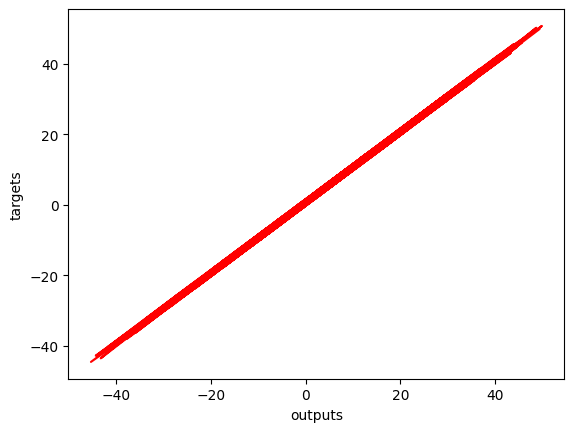

In [9]:
plt.plot(outputs, targets, color='red')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()